# Optimizer profile: overview
Peak GPU memory and steady-state step time for every baseline and every Sven variant, per architecture, at the
training set point (`study == "methods"`). Produced by `experiments/optimizer_profile.py` on an exclusively reserved node.

* **Sven (Gram, hooks)**: per-layer kernel, no Jacobian. Not possible for the batch-statistics ResNet.
* **Sven (Gram, full $J$)**: one `jacrev`, the $B\times P$ Jacobian, its Gram matrix, `eigh`.
* **Sven (Gram, chunked)**: the same in parameter groups of $f\cdot P$ (here $f=0.25$).
* **Sven (classic, rand. SVD)**: the $B\times P$ Jacobian and a randomized-SVD pseudo-inverse (`randomized_v2`).

In [1]:
import sys
sys.path.insert(0, '.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from style import set_style
import profile_helpers as ph
set_style()
PLOT_DIR = 'plots_v2/profile'
# $SV3_PROFILE_ROOT > profile_results_v3 (the re-measurement, once its 720 configurations
# are all there) > profile_results_v2.  A PARTIAL v3 is announced and skipped, not used.
ROOT = ph.results_root()         # prints which root it chose
df = ph.load_profiles(ROOT)      # one tidy row per configuration
ARCHS = [a for a in ph.ARCH_ORDER if a in set(df.arch)]
df.groupby(['arch', 'study']).size().unstack(fill_value=0)

profile results: /n/home11/sambt/iaifi/sv3/profile_results_v2  (v2)


720 configurations from /n/home11/sambt/iaifi/sv3/profile_results_v2/ ({'ok': 709, 'error': 8, 'infeasible': 2, 'oom': 1})


study,batch_size,chunk_fraction,k,methods,microbatch,param_fraction,width
arch,,,,,,,
cifar_resnet18,16,5,8,16,10,26,0
mnist,36,6,15,17,21,48,0
mnist_width,0,0,0,0,0,0,91
nanogpt,25,5,12,17,15,18,0
nanogpt_width,0,0,0,0,0,0,55
polynomial,36,4,15,17,18,39,0
toy_1d,36,4,15,17,18,39,0


### Measurement quality
Step times are the **steady-state mean**: the first 20% of measured steps and any >3 MAD spike are dropped.
The panel below is the p90/p10 ratio of the raw per-step times for every configuration; anything above 1.3 is listed.

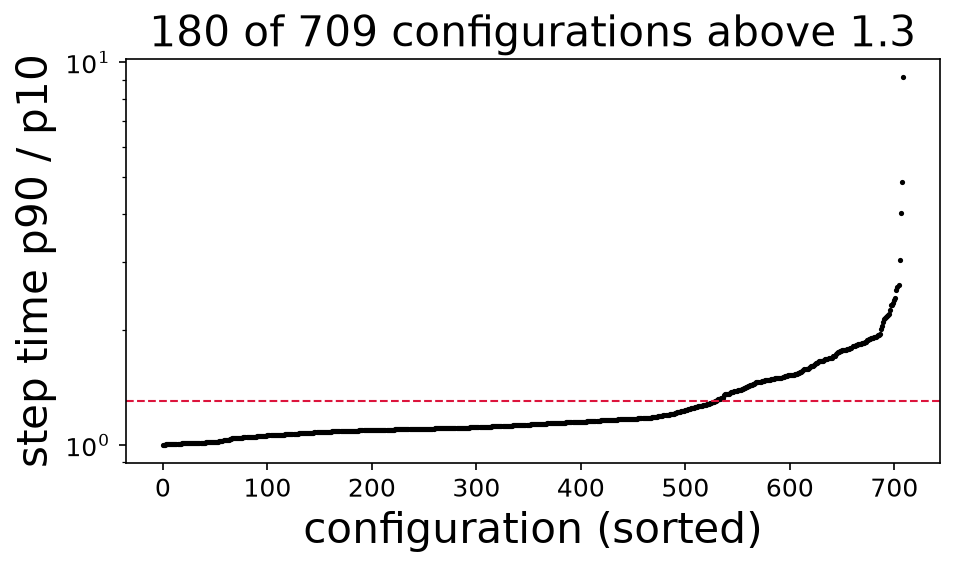

,arch,study,method,B,step_ms,step_ms_p10,step_ms_p90,steadiness,status
97,mnist,batch_size,SGD,512,3.853677,3.071994,4.009427,1.305155,ok
383,nanogpt,microbatch,gram_full,64,107.283493,98.686031,129.407651,1.311307,ok
215,mnist,param_fraction,gram_hooks,64,12.241302,11.561565,15.198797,1.314597,ok
113,mnist,batch_size,gram_hooks,256,11.432444,10.309648,13.567571,1.316007,ok
494,polynomial,batch_size,gram_hooks,256,12.455722,11.674544,15.369526,1.316499,ok
18,cifar_resnet18,chunk_fraction,gram_chunked,128,470.148228,403.727011,534.100195,1.322924,ok
496,polynomial,batch_size,gram_hooks,64,12.210318,11.237984,14.898071,1.325689,ok
100,mnist,batch_size,classic,16,12.386666,10.841172,14.395923,1.327894,ok
486,polynomial,batch_size,gram_full,128,18.315554,16.522839,22.271618,1.347929,ok
476,polynomial,batch_size,SGD,256,3.633949,3.182458,4.311837,1.354876,ok


In [2]:
fig, ax = plt.subplots(figsize=(7, 3.5))
unsteady = ph.plot_steadiness(df, ax)
ph.save(fig, 'qc_steadiness.pdf', PLOT_DIR); plt.show()
unsteady.head(20)

### Anything that did not run
Out-of-memory and analytically infeasible configurations are results, not failures; genuine errors are listed too.

In [3]:
ph.status_report(df)

,arch,study,method,B,pf,mask_mode,mb,width,status,error
0,cifar_resnet18,methods,HIG,128,1.00,none,1,NaN,infeasible,HIG output Jacobian is 57.3 GB (128x10 rows x ...
1,cifar_resnet18,param_fraction,classic,128,0.05,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
2,cifar_resnet18,param_fraction,classic,128,0.10,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
3,cifar_resnet18,param_fraction,classic,128,0.25,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
4,cifar_resnet18,param_fraction,classic,128,0.50,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
5,mnist,param_fraction,classic,64,0.05,rows,1,NaN,error,_LinAlgError: linalg.eigh: The algorithm faile...
6,mnist,param_fraction,gram_hooks,64,0.05,rows,1,NaN,error,_LinAlgError: linalg.eigh: The algorithm faile...
7,mnist_width,width,HIG,64,1.00,none,1,1024.0,error,_LinAlgError: cusolver error: CUSOLVER_STATUS_...
8,mnist_width,width,HIG,64,1.00,none,1,2048.0,oom,CUDA out of memory. Tried to allocate 23.89 Gi...
9,nanogpt,methods,HIG,64,1.00,none,1,NaN,infeasible,HIG output Jacobian is 1760.1 GB (64x8320 rows...


### Per-architecture method tables

In [4]:
tables = {}
for arch in ARCHS:
    tables[arch] = ph.method_table(df, arch)
    print(f"\n=== {ph.ARCH_TITLES.get(arch, arch)} ===")
    display(tables[arch])
    tables[arch].to_csv(f'{PLOT_DIR}/table_methods_{arch}.csv', index=False) if __import__('os').makedirs(PLOT_DIR, exist_ok=True) is None else None
    open(f'{PLOT_DIR}/table_methods_{arch}.tex', 'w').write(tables[arch].to_latex(index=False, na_rep='--', float_format='%.3g'))


=== Toy 1D MLP ===


,Method,Step (ms),x Adam,Peak mem (MB),x SGD,Capture (ms),Solve+apply (ms),p90/p10,Note
0,"Sven (classic, rand. SVD)",10.46,2.81,22.2,1.23,7.50,2.96,1.16,
1,"Sven (Gram, hooks)",11.64,3.13,18.9,1.04,4.89,6.75,1.12,
2,"Sven (Gram, full $J$)",15.33,4.12,18.9,1.04,7.77,7.55,1.11,
3,"Sven (Gram, chunked)",162.71,43.70,18.9,1.04,154.66,8.05,1.01,
4,SGD,3.50,0.94,18.1,1.00,NaN,NaN,1.09,
5,RMSprop,3.69,0.99,18.1,1.00,NaN,NaN,1.08,
6,AdamW,3.72,1.00,18.1,1.00,NaN,NaN,1.09,
7,Adam,3.76,1.01,18.1,1.00,NaN,NaN,1.15,
8,PolyakSGD,4.04,1.09,18.1,1.00,NaN,NaN,1.11,
9,Muon,5.09,1.37,18.1,1.00,NaN,NaN,1.04,



=== Polynomial MLP ===


,Method,Step (ms),x Adam,Peak mem (MB),x SGD,Capture (ms),Solve+apply (ms),p90/p10,Note
0,"Sven (classic, rand. SVD)",10.40,2.85,22.2,1.23,7.36,3.05,1.14,
1,"Sven (Gram, hooks)",11.51,3.16,18.9,1.04,4.80,6.71,1.10,
2,"Sven (Gram, full $J$)",15.20,4.17,18.9,1.04,7.66,7.54,1.08,
3,"Sven (Gram, chunked)",162.42,44.53,18.9,1.04,154.20,8.22,1.01,
4,SGD,3.49,0.96,18.1,1.00,NaN,NaN,1.15,
5,RMSprop,3.61,0.99,18.1,1.00,NaN,NaN,1.11,
6,AdamW,3.65,1.00,18.1,1.00,NaN,NaN,1.09,
7,Adam,3.66,1.00,18.1,1.00,NaN,NaN,1.12,
8,PolyakSGD,3.84,1.05,18.1,1.00,NaN,NaN,1.10,
9,Muon,5.34,1.46,18.1,1.00,NaN,NaN,1.01,



=== MNIST MLP ===


,Method,Step (ms),x Adam,Peak mem (MB),x SGD,Capture (ms),Solve+apply (ms),p90/p10,Note
0,"Sven (Gram, hooks)",10.40,2.46,20.9,1.05,3.86,6.54,1.11,
1,"Sven (classic, rand. SVD)",15.51,3.67,48.5,2.43,9.83,5.68,1.61,
2,"Sven (Gram, full $J$)",19.37,4.59,48.6,2.44,9.59,9.78,1.48,
3,"Sven (Gram, chunked)",163.77,38.78,45.5,2.28,151.89,11.89,1.08,
4,SGD,3.97,0.94,19.9,1.00,NaN,NaN,1.24,
5,Adam,4.09,0.97,20.3,1.02,NaN,NaN,1.23,
6,PolyakSGD,4.11,0.97,19.9,1.00,NaN,NaN,1.11,
7,RMSprop,4.12,0.98,20.1,1.01,NaN,NaN,1.06,
8,AdamW,4.22,1.00,20.3,1.02,NaN,NaN,1.08,
9,Muon,5.39,1.28,20.2,1.02,NaN,NaN,1.02,



=== nanoGPT ===


,Method,Step (ms),x Adam,Peak mem (MB),x SGD,Capture (ms),Solve+apply (ms),p90/p10,Note
0,"Sven (Gram, hooks)",83.18,3.54,615.2,1.91,41.83,41.35,1.86,
1,"Sven (Gram, full $J$)",257.43,10.96,2893.1,8.99,217.47,39.96,1.18,
2,"Sven (classic, rand. SVD)",266.59,11.35,2893.1,8.99,248.64,17.95,1.17,
3,"Sven (Gram, chunked)",445.62,18.98,2625.4,8.16,409.60,36.02,1.06,
4,SGD,20.99,0.89,321.9,1.00,NaN,NaN,1.05,
5,RMSprop,22.69,0.97,325.2,1.01,NaN,NaN,1.04,
6,Adam,23.43,1.00,328.5,1.02,NaN,NaN,1.04,
7,AdamW,23.51,1.00,328.5,1.02,NaN,NaN,1.04,
8,PolyakSGD,28.75,1.22,321.9,1.00,NaN,NaN,1.08,
9,Muon,32.58,1.39,325.2,1.01,NaN,NaN,1.08,



=== CIFAR-10 ResNet18 ===


,Method,Step (ms),x Adam,Peak mem (MB),x SGD,Capture (ms),Solve+apply (ms),p90/p10,Note
0,"Sven (Gram, chunked)",470.22,19.60,6922.7,36.25,411.24,58.98,1.36,
1,"Sven (Gram, full $J$)",841.97,35.10,22977.7,120.30,745.66,96.31,2.18,
2,"Sven (classic, rand. SVD)",1126.17,46.95,23033.0,120.59,942.01,184.16,1.05,
3,SGD,22.31,0.93,191.0,1.00,NaN,NaN,1.04,
4,RMSprop,23.18,0.97,238.7,1.25,NaN,NaN,1.07,
5,Adam,23.94,1.00,282.6,1.48,NaN,NaN,1.07,
6,AdamW,23.99,1.00,283.6,1.48,NaN,NaN,1.09,
7,Muon,24.83,1.03,283.6,1.48,NaN,NaN,1.14,
8,PolyakSGD,24.86,1.04,191.0,1.00,NaN,NaN,1.16,
9,SOAP,49.72,2.07,312.8,1.64,NaN,NaN,1.18,


### Step time and peak memory, per architecture

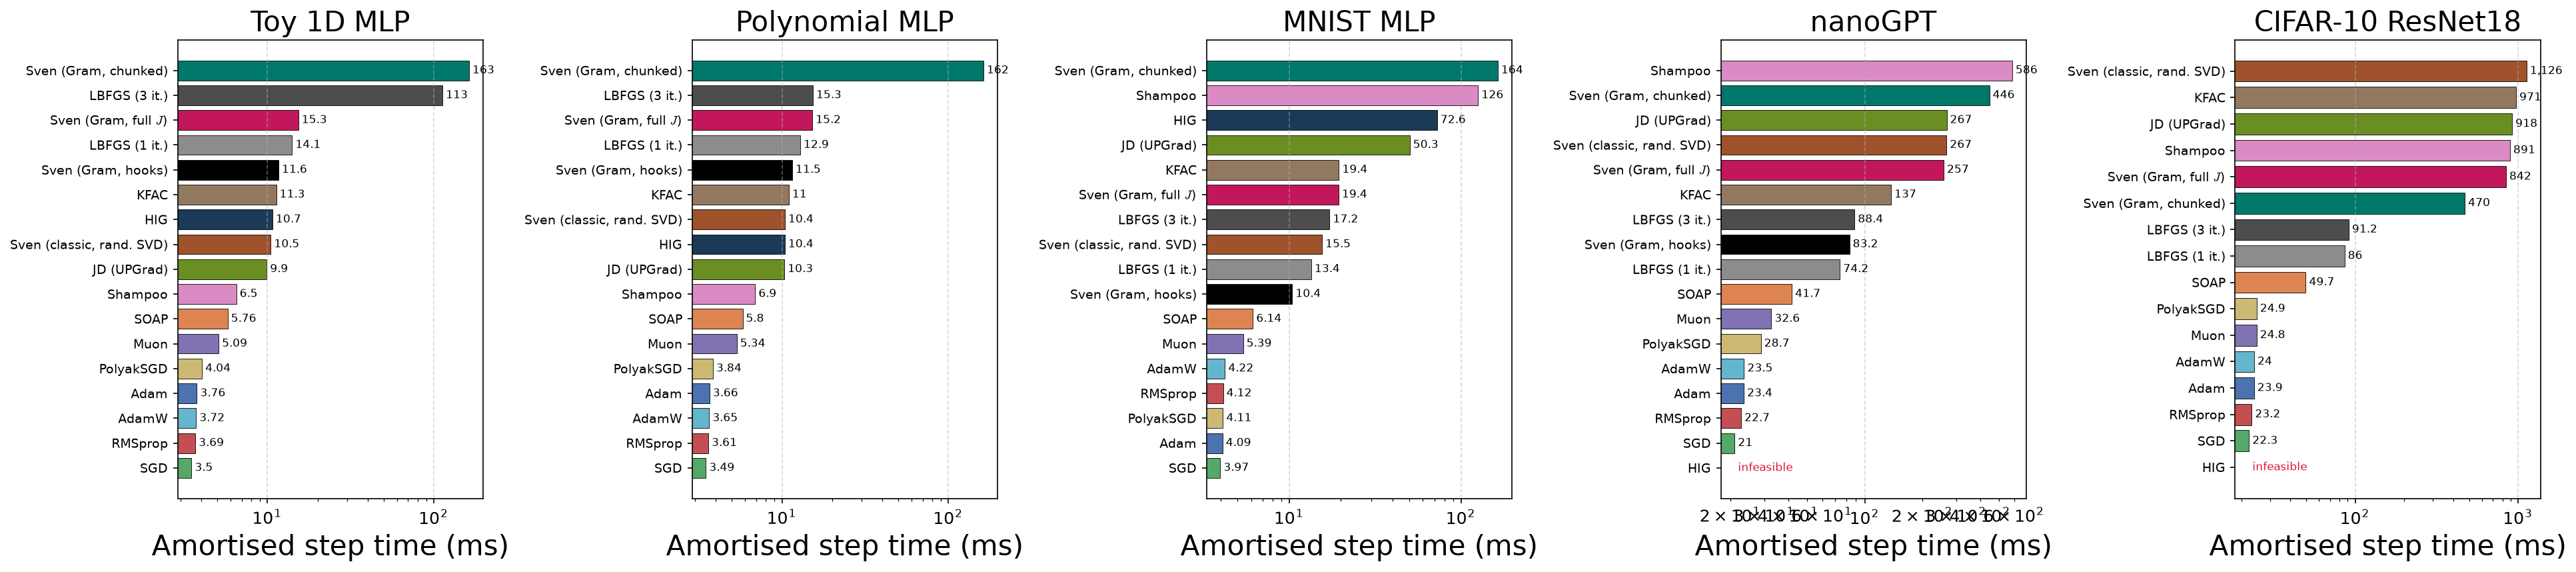

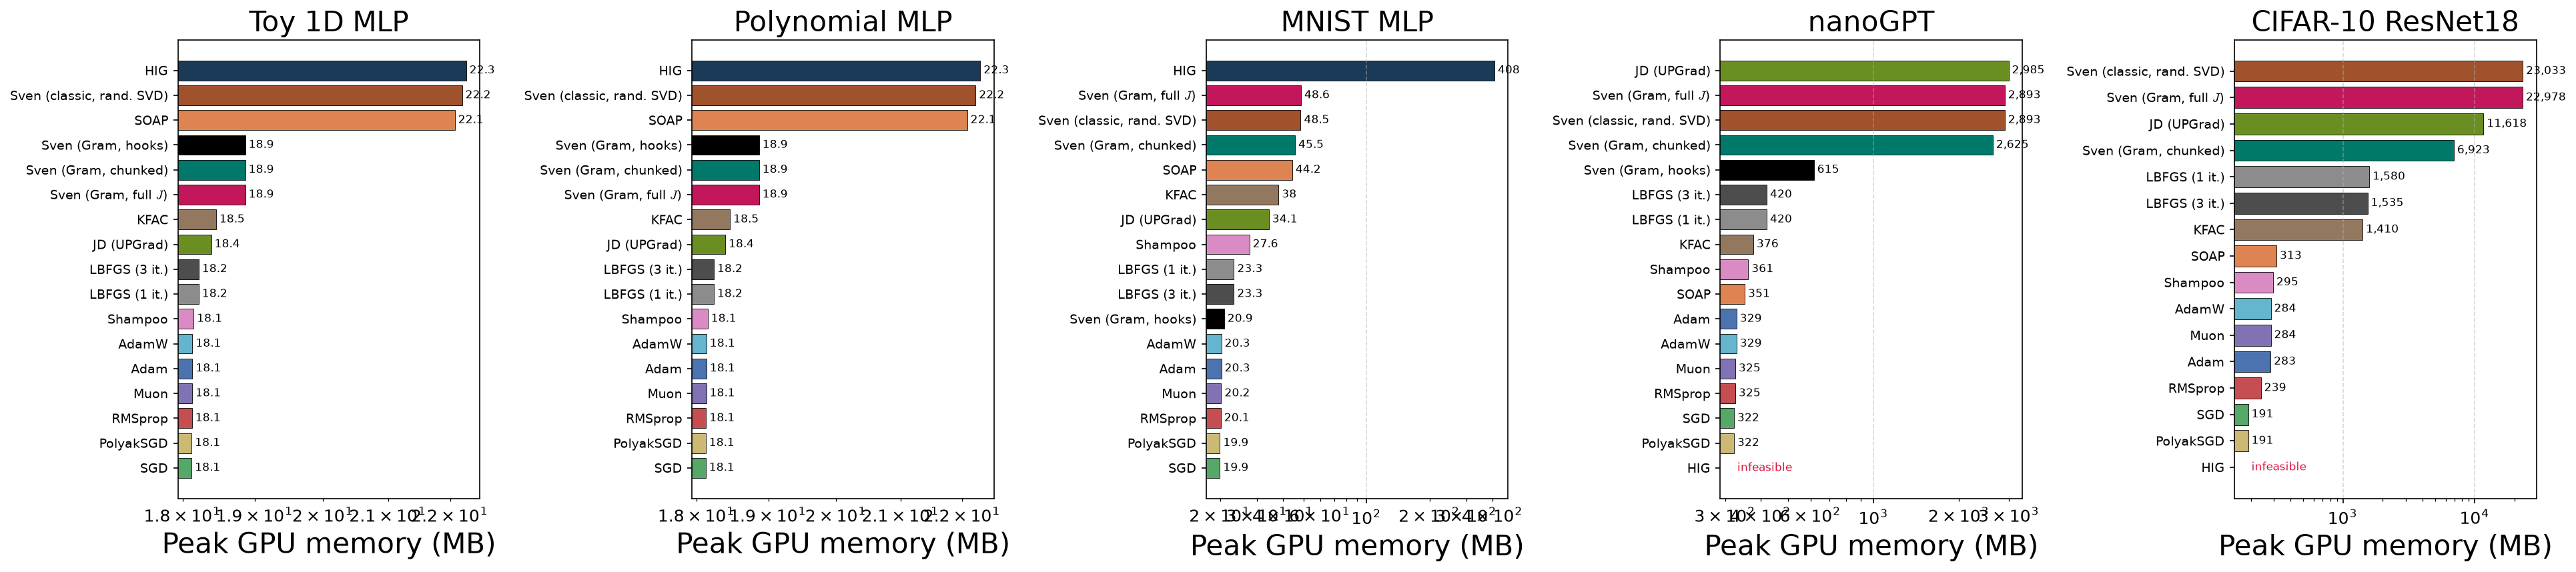

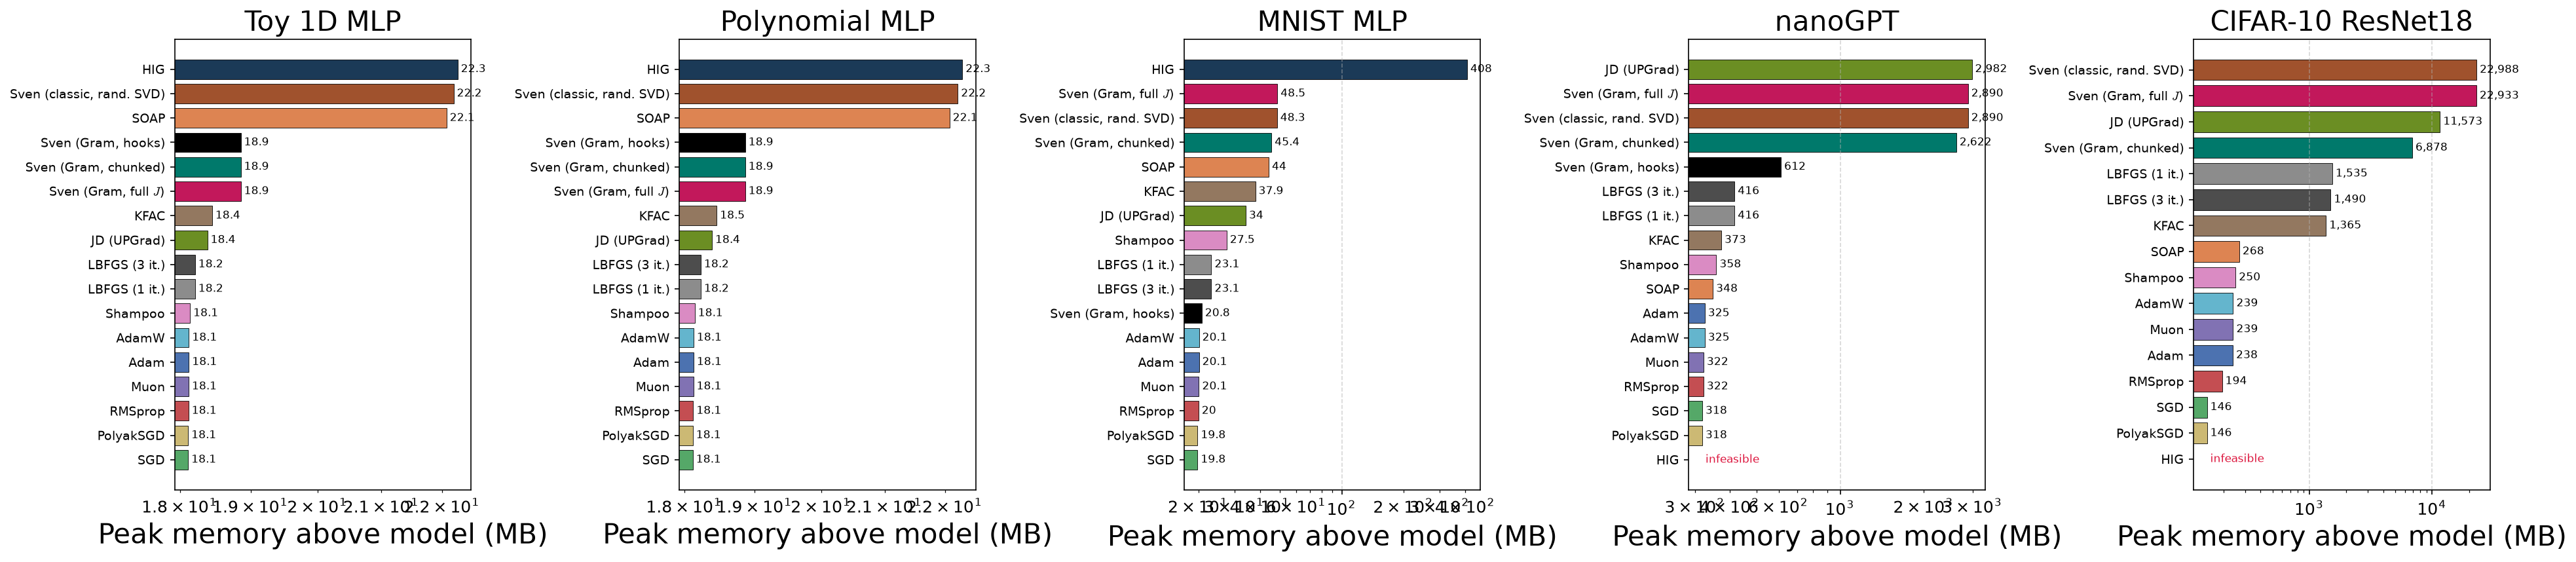

In [5]:
for value, fname in [('step_ms', 'methods_step_time'), ('peak_mb', 'methods_peak_memory'), ('overhead_mb', 'methods_memory_overhead')]:
    fig, axes = plt.subplots(1, len(ARCHS), figsize=(5.2 * len(ARCHS), 6), squeeze=False)
    for ax, arch in zip(axes[0], ARCHS):
        ph.plot_method_bars(df, arch, ax, value=value)
    fig.tight_layout(); ph.save(fig, f'{fname}.pdf', PLOT_DIR); plt.show()

### Cross-architecture summary
Step time relative to Adam and peak memory relative to SGD, same architecture and batch size.

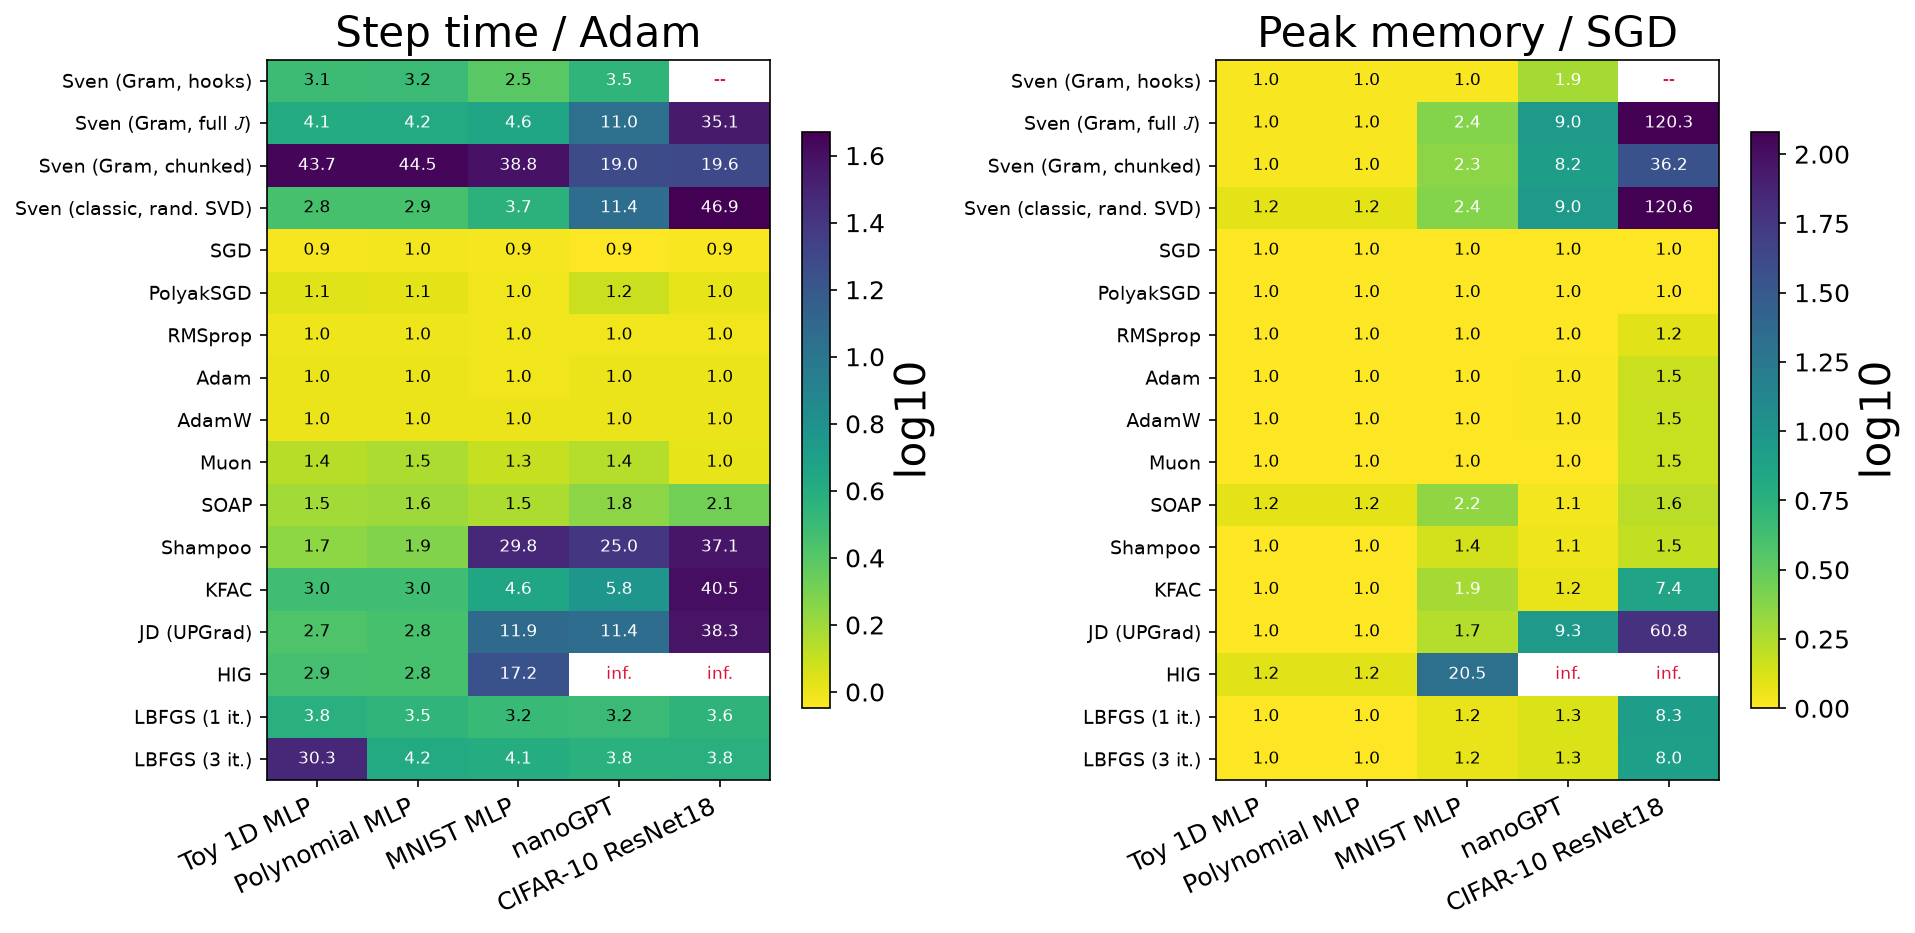

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, (value, title) in zip(axes, [('rel_time', 'Step time / Adam'), ('rel_mem', 'Peak memory / SGD')]):
    im = ph.plot_heatmap(df, ax, value=value); ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8, label='log10')
fig.tight_layout(); ph.save(fig, 'summary_heatmaps.pdf', PLOT_DIR); plt.show()

### Where a Sven step spends its time
Solid: capture (`loss_and_grad`: forward, Jacobian or Gram). Hatched: solve and apply (`optimizer.step`).

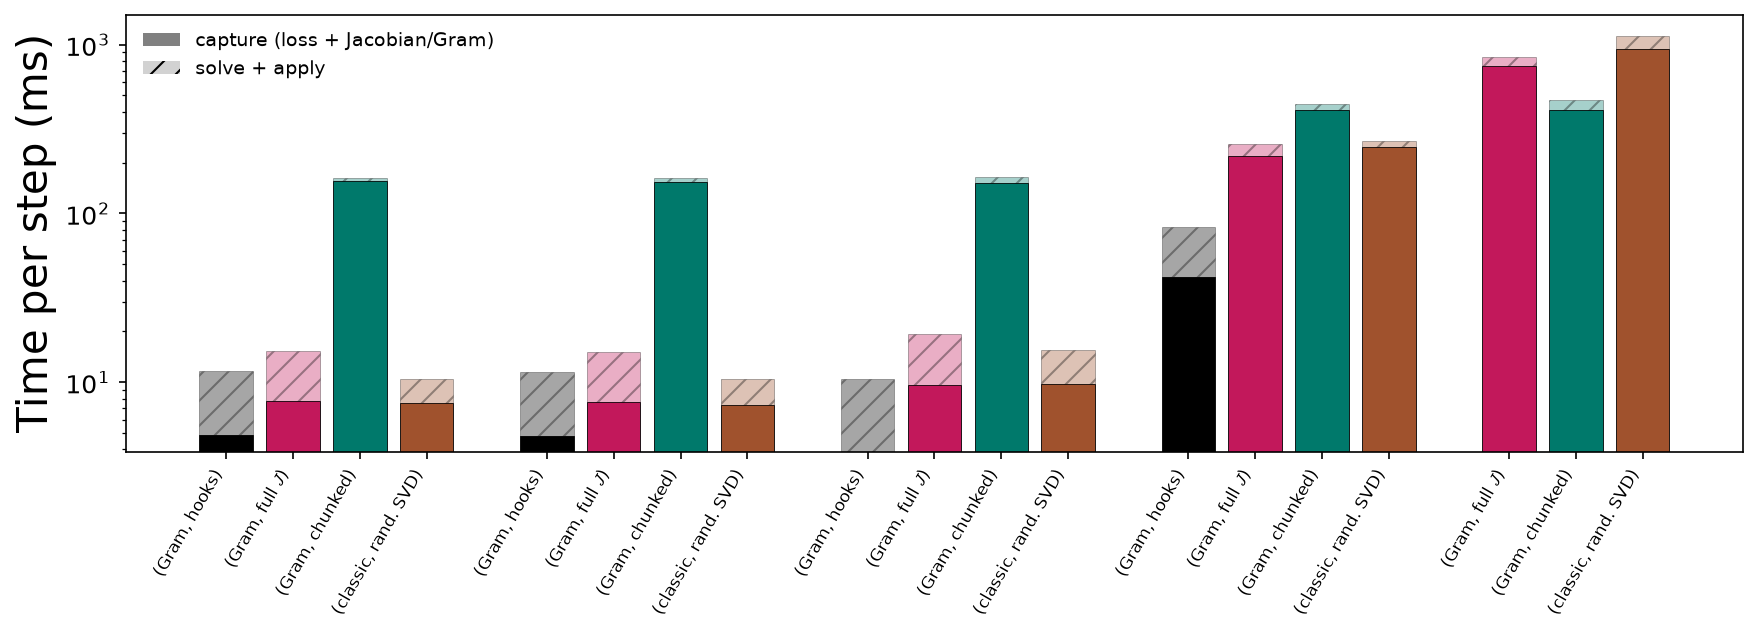

In [7]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ph.plot_phase_bars(df, ax)
fig.tight_layout(); ph.save(fig, 'sven_phase_breakdown.pdf', PLOT_DIR); plt.show()

### v2 vs v3: what the re-measurement changed
`profile_results_v2` (2026-09-17) got TWO settings wrong: Sven's per-step `torch.cuda.empty_cache()` and the
missing `expandable_segments` allocator. `profile_results_v3` fixes both (ANALYSIS_PLAN.md section 7.4), so the
Sven variants are expected to get FASTER -- up to ~4.5x for full capture on CIFAR -- while the baselines,
which never called `empty_cache`, should not move. A baseline that does move points at different hardware or a
busy node, not at the fix: check `gpu_old`/`gpu_new` below and the two `[calib]` lines in the profile job's log.

The BatchNorm policy is **not** one of the differences, though the commit that set up v3 touched it: every v2
CIFAR Gram record carries `meta.freeze_norm_stats: False`, i.e. v2 already profiled CIFAR with the batch
statistics its scans use (the pre-C-E2 config still set `gram_freeze_norm_stats: false`). What v3's `bn_mode`
plumbing prevents is a *future* regression -- C-E2 removed that key, after which the profiler's own default
would have frozen CIFAR's statistics.

The cell is inert until v3 is COMPLETE (it prints what is missing and stops), so this notebook runs either way;
`ph.results_root()` likewise keeps every table above on v2 until all 720 configurations have landed.


In [8]:
cmp = ph.compare_profiles()                      # v2 -> v3, joined on run_id
if len(cmp):
    print('GPU:', sorted(set(cmp.gpu_old.dropna())), '->', sorted(set(cmp.gpu_new.dropna())))
    print(f'{int(cmp.status_old.isna().sum())} configuration(s) only in v3, '
          f'{int(cmp.status_new.isna().sum())} only in v2')
    display(ph.compare_table(cmp, study='methods', value='step_ms'))
    display(ph.compare_table(cmp, study='methods', value='peak_mb', n=15))
    # the headline of the whole re-run: Sven's set-point step time, v2 -> v3
    sven = cmp[(cmp.study == 'methods') & cmp.method.isin(ph.SVEN)]
    display(sven.set_index(['arch', 'method'])[['step_ms_old', 'step_ms_new', 'step_ms_ratio',
                                                'peak_mb_old', 'peak_mb_new']].round(2))
cmp.head()

v2-vs-v3 comparison: nothing to compare yet (old=ok profile_results_v2, new=missing profile_results_v3)


""
